In [1]:
import omegaconf
import torch
import logging
import numpy as np
from torch.utils.data import DataLoader, Sampler

from physicsnemo.sym.hydra import to_absolute_path
from physicsnemo.sym.key import Key
from physicsnemo.sym.distributed.manager import DistributedManager

import physicsnemo.sym
from physicsnemo.sym.hydra import to_absolute_path, instantiate_arch, PhysicsNeMoConfig
from physicsnemo.sym.key import Key

from physicsnemo.sym.dataset import HDF5GridDataset
# Running predictions
import matplotlib.pyplot as plt
import numpy as np
import h5py
import sys

import os

pth_utilities = '/home/edwinobando/PINN/physicsnemo-sym/examples/darcy/utilities.py'
if os.path.exists(pth_utilities):
    sys.path.append(os.path.dirname(pth_utilities))
else:
    raise FileNotFoundError(f"File not found: {pth_utilities}")
from utilities import download_FNO_dataset, load_FNO_dataset


In [2]:
# compute MAE
def compute_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# compute MAPE
def compute_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
# compute RMSE
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [3]:
test_path = '/home/edwinobando/PINN/01_AI_Geophysics_Inversion/database/hdf5_files/dataset_CASE_II_source_5m_test.hdf5'
dataset = HDF5GridDataset(
    test_path, invar_keys=["X"], outvar_keys=["Y"], n_examples=200
)

# for iterable datasets, must do batching/sampling within dataset
dataloader = DataLoader(
    dataset,
    batch_size=32,
    pin_memory=True,
    num_workers=10,
    worker_init_fn=dataset.worker_init_fn,
)


dataloader = iter(dataloader)

/home/edwinobando/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=9650) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


In [4]:
# load configuration
cfg = omegaconf.OmegaConf.load("/home/edwinobando/PINN/01_AI_Geophysics_Inversion/MODELS_2D_Reconstructed/outputs/run_variable_velocity_Case_II_source_5m/.hydra/config.yaml")
model_path = to_absolute_path("/home/edwinobando/PINN/01_AI_Geophysics_Inversion/MODELS_2D_Reconstructed/outputs/run_variable_velocity_Case_II_source_5m/fno.0.pth")

# get device
device = DistributedManager().device


def to_device(tensor_dict):
    return {
        key: torch.as_tensor(value, dtype=torch.float32, device=device)
        for key, value in tensor_dict.items()
    }


In [5]:

input_keys = [Key("X", scale=(0, 1))]
output_keys = [Key("Y", scale=(0,  1))]

# [init-model]
# make list of nodes to unroll graph on
decoder_net = instantiate_arch(
    cfg=cfg.arch.decoder,
    output_keys=output_keys,
)

model = instantiate_arch(
    cfg=cfg.arch.fno,
    input_keys=input_keys,
    decoder_net=decoder_net,
    activation_fn = 'tanh',
    decoder_activation_fn = 'tanh',
)


# load parameters
model.load_state_dict(torch.load(model_path))
model.to(device)
logging.info(f"Loaded model {model_path}")

In [6]:
# Run prediction
model.eval()
with torch.no_grad():
    for i, batch_ in enumerate(dataloader):
        x,y = batch_[0], batch_[1]

        # Convert to device
        x = to_device(x)
        y = to_device(y)
        pred = model(x)



In [7]:
Y_min = 80.00116347553661 
Y_max = 249.97346219502631


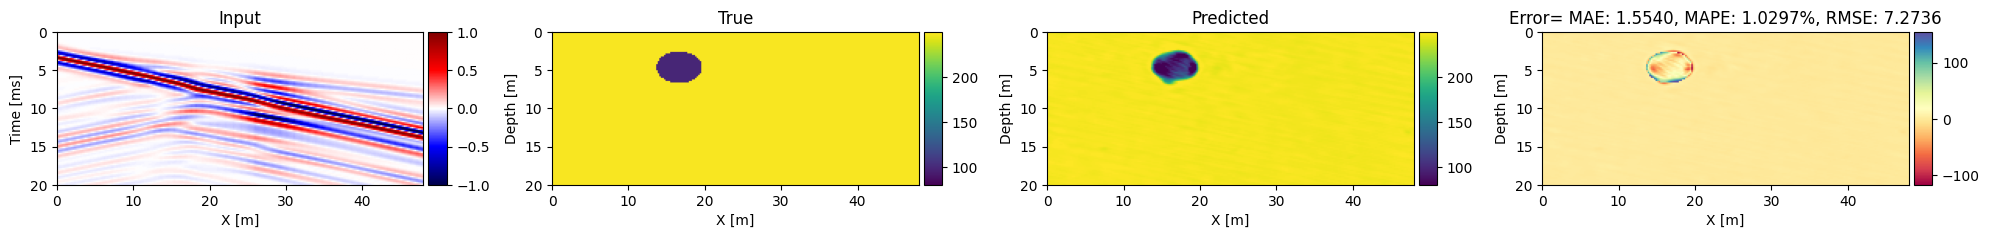

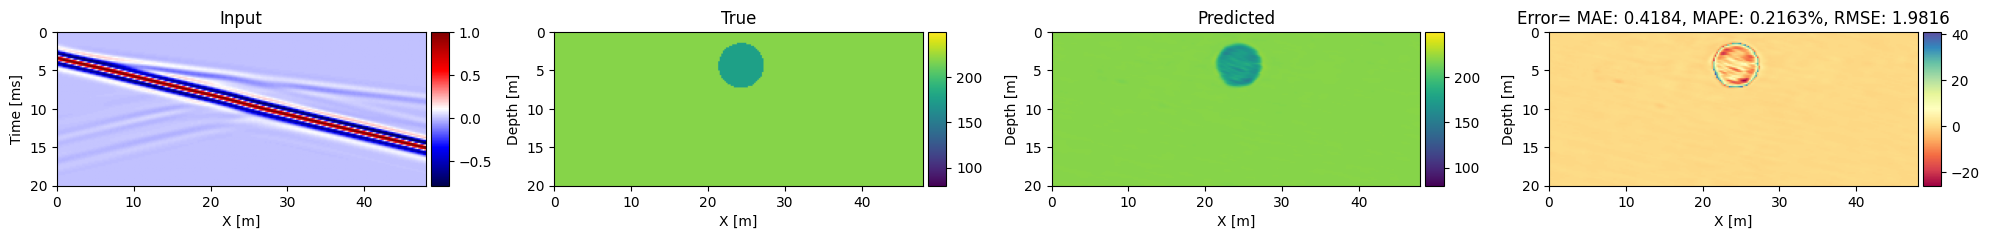

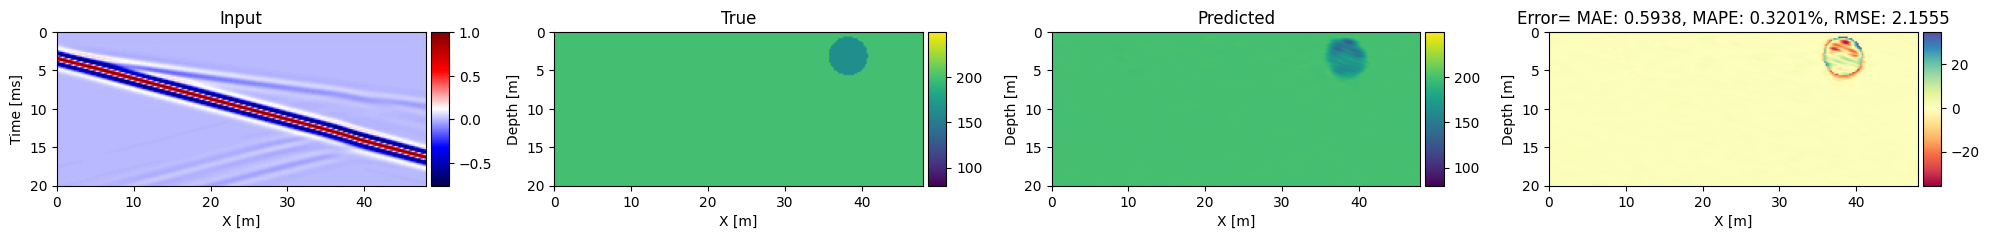

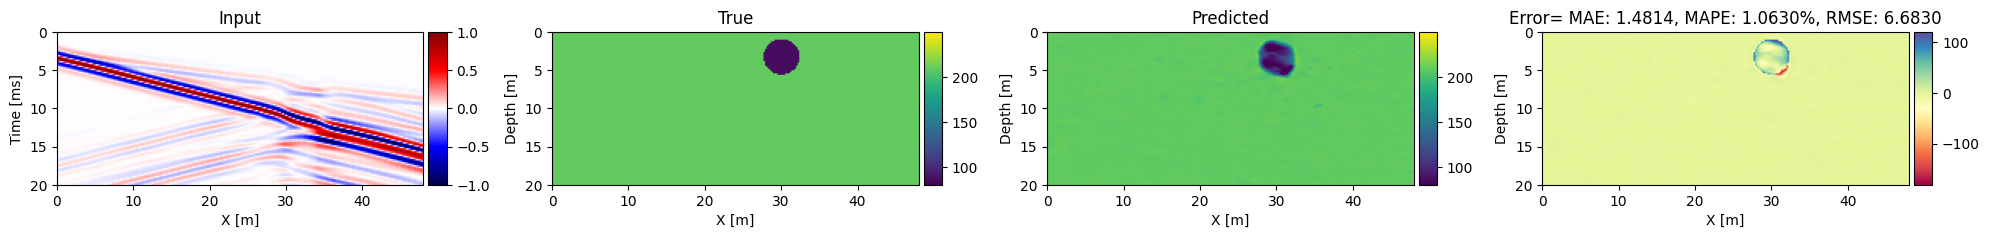

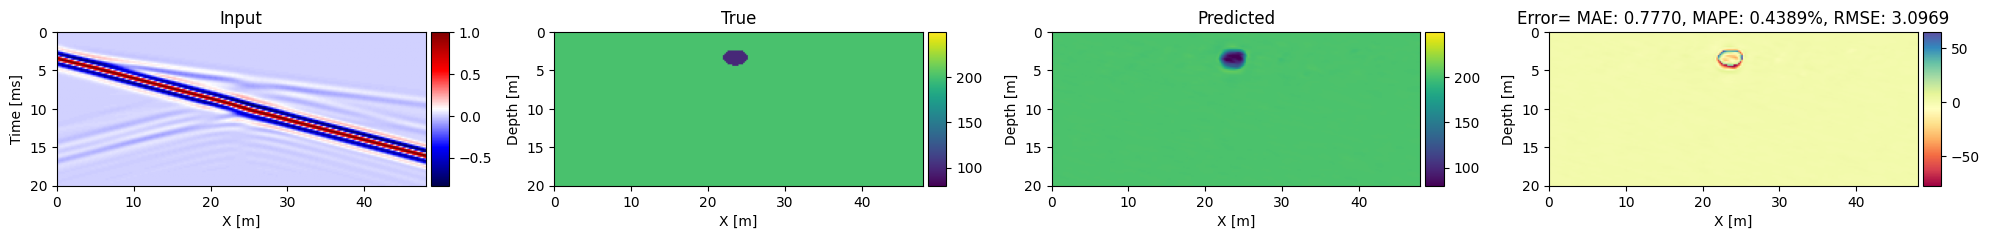

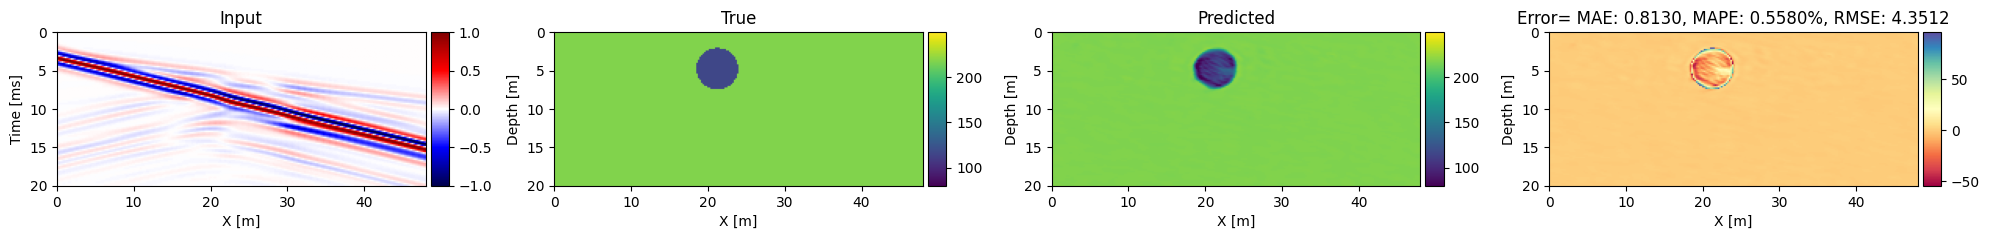

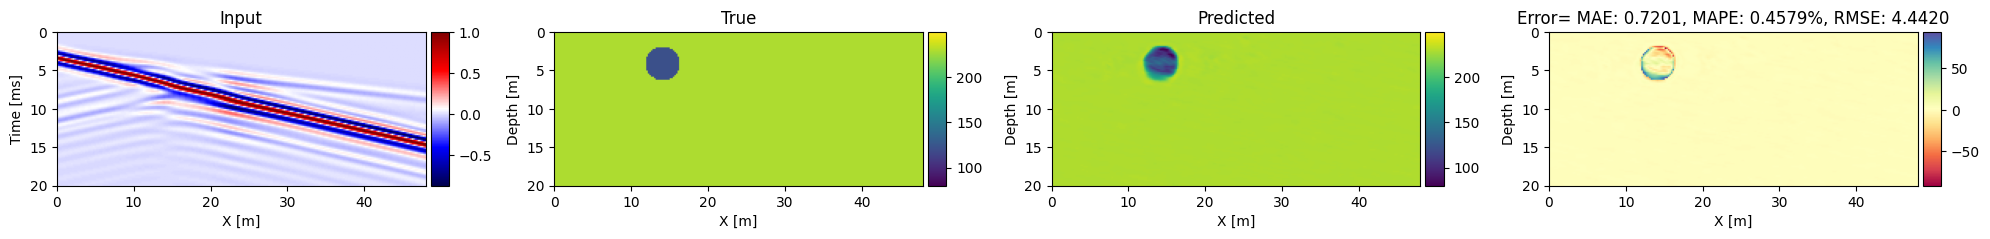

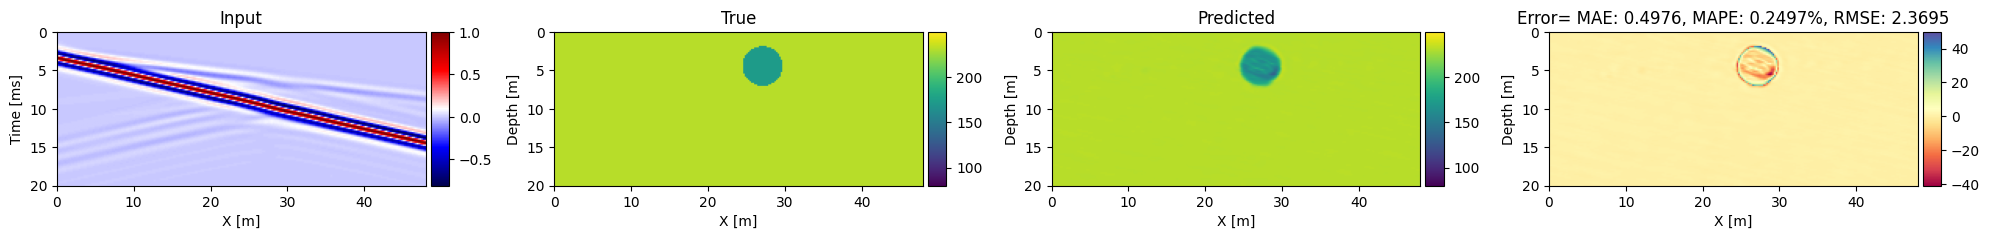

In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


for i in range(8):

    fig, (ax0, ax1, ax2, ax3) = plt.subplots(1, 4, figsize=(20, 12))


    # denormalize from -1 to 1. Use X_min, X_max, Y_min, Y_max.

    x_ = x['X'][i, 0].cpu().numpy()
    y_ = y['Y'][i, 0].cpu().numpy()
    pred_ = pred['Y'][i, 0].cpu().numpy()

    y_ = (y_ + 1) / 2 * (Y_max - Y_min) + Y_min
    pred_ = (pred_ + 1) / 2 * (Y_max - Y_min) + Y_min



    im0 = ax0.imshow(np.flipud(x_.T), cmap='seismic',extent=(0, 48, 1000*100*2e-4,0))
    divider = make_axes_locatable(ax0)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im0, cax=cax)
    ax0.set_title("Input")
    ax0.set_xlabel("X [m]")
    ax0.set_ylabel("Time [ms]")


    im1 = ax1.imshow(np.flipud(y_.T), cmap='viridis',extent=(0, 48, 20,0), vmin=Y_min, vmax=Y_max)

    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im1, cax=cax)
    ax1.set_title("True")
    ax1.set_xlabel("X [m]")
    ax1.set_ylabel("Depth [m]")

    im2 = ax2.imshow(np.flipud(pred_.T), cmap='viridis',extent=(0, 48, 20,0), vmin=Y_min, vmax=Y_max)
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im2, cax=cax)
    ax2.set_title("Predicted")
    ax2.set_xlabel("X [m]")
    ax2.set_ylabel("Depth [m]")


    # compute error
    error = pred_ - y_
    # compute MAE, MAPE, RMSE
    mae = compute_mae(y_, pred_)
    mape = compute_mape(y_, pred_)
    rmse = compute_rmse(y_, pred_)
    



    im3 = ax3.imshow(np.flipud(error.T), cmap='Spectral',extent=(0, 48, 20,0))
    divider = make_axes_locatable(ax3)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im3, cax=cax)
    ax3.set_title("Error= MAE: {:.4f}, MAPE: {:.4f}%, RMSE: {:.4f}".format(mae, mape, rmse))
    ax3.set_xlabel("X [m]")
    ax3.set_ylabel("Depth [m]")


    fig.tight_layout()

    plt.savefig(f"predictions_CASE_II_source_5m_{i}.png")

